In [2]:
import os, pathlib
import pandas as pd

df = pd.read_csv("./CEAS_08.csv")
# df.head()



# Take a subset of the dataset (20% of each label)
df_label_0 = df[df['label'] == 0].sample(frac=0.06, random_state=42)
df_label_1= df[df['label'] == 1].sample(frac=0.06, random_state=42)

df = pd.concat([df_label_0, df_label_1]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"New dataset size: {len(df)}")
print("Distribution of labels in the subset:")
print(df['label'].value_counts())


New dataset size: 2350
Distribution of labels in the subset:
label
1    1311
0    1039
Name: count, dtype: int64


Imports & Setup

In [3]:
from __future__ import annotations
import os
import gc
from dataclasses import dataclass
from typing import List, Tuple, Optional

import pandas as pd
import torch
from torch.utils.data import Dataset as TorchDataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

from datetime import datetime
from tqdm.notebook import tqdm
import math
import json
import sys

2025-10-01 02:37:38.992140: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759264659.017612  947125 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759264659.027036  947125 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759264659.048894  947125 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759264659.048919  947125 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759264659.048921  947125 computation_placer.cc:177] computation placer alr

In [4]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()


GPU Sanity Check

In [5]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))

Torch version: 2.8.0+cu128
CUDA available: True
Device count: 1
Device name: NVIDIA GeForce RTX 4060 Ti


Log Message Utility

In [6]:
# ----------------------------
# Simple Logging Utility
# ----------------------------
from datetime import datetime

def log_message(save_dir: str, msg: str, console: bool = True):
    log_path = os.path.join(save_dir, "training_log.txt")
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{timestamp}] {msg}\n"
    with open(log_path, "a") as f:
        f.write(line)
    if console:
        print(line, end="")

Dataset Utilities

In [7]:
@dataclass
class EncodedBatch:
    input_ids: torch.Tensor
    attention_mask: torch.Tensor
    labels: torch.Tensor


class TextClassificationDataset(TorchDataset):
    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_length: int = 256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        enc = self.tokenizer(
            text,
            truncation=True,
            padding=False,
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

albert-based classifier

In [8]:
def train_discriminator(
    train_df: pd.DataFrame,
    save_dir: str = "./albert_game_model",
    model_name: str = "albert-base-v2",
    max_length: int = 256,
    train_batch_size: int = 16,
    learning_rate: float = 5e-5,
    num_train_epochs: int = 3,
    gradient_accumulation_steps: int = 1,
    fp16: bool = True,
    weight_decay: float = 0.01,
    logging_steps: int = 1,
    seed: int = 42,
    round_id: Optional[int] = None,
):
    """
    Train a PyTorch ALBERT classifier on the given training set.
    Skips training if a model already exists in `save_dir`.
    Returns: (model, tokenizer)
    """
    assert {"body", "label"}.issubset(train_df.columns)
    model_save_dir = os.path.join(save_dir, "model")
    os.makedirs(model_save_dir, exist_ok=True)
    set_seed(seed)

    round_tag = f"[Round {round_id}]" if round_id else "[Discriminator]"

    # Skip training if model already exists
    model_file = os.path.join(model_save_dir, "model.safetensors")
    config_file = os.path.join(model_save_dir, "config.json")
    if os.path.exists(model_file) and os.path.exists(config_file):
        tokenizer = AutoTokenizer.from_pretrained(model_save_dir)
        model = AutoModelForSequenceClassification.from_pretrained(model_save_dir)
        log_message(save_dir, f"{round_tag} Found existing model in {model_save_dir}. Skipping training.")
        return model, tokenizer

    # Default: Load tokenizer & model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    num_labels = int(pd.Series(train_df["label"]).nunique())
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

    # Dataset
    train_ds = TextClassificationDataset(
        train_df["body"].astype(str).tolist(),
        train_df["label"].astype(int).tolist(),
        tokenizer,
        max_length,
    )

    # Training args (no eval set)
    args = TrainingArguments(
        output_dir=save_dir,
        per_device_train_batch_size=train_batch_size,
        learning_rate=learning_rate,
        num_train_epochs=num_train_epochs,
        gradient_accumulation_steps=gradient_accumulation_steps,
        fp16=fp16,
        weight_decay=weight_decay,
        logging_steps=logging_steps,
        save_strategy="epoch",
        save_total_limit=2,
        report_to=[],
        logging_strategy="steps",
        logging_dir=os.path.join(save_dir, "runs"),
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        tokenizer=tokenizer,
    )

    log_message(save_dir, f"{round_tag} Starting training...")
    trainer.train()

    trainer.save_model(model_save_dir)
    tokenizer.save_pretrained(model_save_dir)
    log_message(model_save_dir, f"{round_tag} Training completed. Model saved to {model_save_dir}")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return model, tokenizer

adversarial sample generation (TextAttack)

In [9]:
from textattack.models.wrappers import HuggingFaceModelWrapper
from textattack.datasets import Dataset as TADataset
from textattack import Attacker, AttackArgs
from textattack.attack_recipes import TextFoolerJin2019, PWWSRen2019, DeepWordBugGao2018
from textattack.attack_results import SuccessfulAttackResult, FailedAttackResult, SkippedAttackResult
from transformers import AutoTokenizer, AutoModelForSequenceClassification

dummy_model_name = "albert-base-v2"  # Small and fast to load
dummy_tokenizer = AutoTokenizer.from_pretrained(dummy_model_name)
dummy_model = AutoModelForSequenceClassification.from_pretrained(dummy_model_name, num_labels=2)

# Create a wrapper
dummy_wrapper = HuggingFaceModelWrapper(dummy_model, dummy_tokenizer)

print("Downloading TextAttack resources...")
for recipe_class in [TextFoolerJin2019, PWWSRen2019, DeepWordBugGao2018]:
    try:
        print(f"Downloading resources for {recipe_class.__name__}...")
        _ = recipe_class.build(dummy_wrapper)  # This will download required embeddings/data
        print(f"✓ {recipe_class.__name__} resources downloaded")
    except Exception as e:
        print(f"⚠ Could not download resources for {recipe_class.__name__}: {e}")

print("All TextAttack resources downloaded successfully!")

/home/nazmul/anaconda3/envs/nlp_game/lib/python3.12/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


textattack: Unknown if model of class <class 'transformers.models.albert.modeling_albert.AlbertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.


✓ TextFoolerJin2019 resources downloaded


[nltk_data] Downloading package omw-1.4 to /home/nazmul/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
textattack: Unknown if model of class <class 'transformers.models.albert.modeling_albert.AlbertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Unknown if model of class <class 'transformers.models.albert.modeling_albert.AlbertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.


✓ PWWSRen2019 resources downloaded
✓ DeepWordBugGao2018 resources downloaded
All TextAttack resources downloaded successfully!


In [10]:
# ---- add a streaming interface to TextAttack.Attacker (runtime patch) ----
import textattack
from textattack.attacker import Attacker as _TA_Attacker
import tqdm as _tqdm
import logging as _logging
import signal
def _timeout_handler(signum, frame):
    raise TimeoutError("Attack took too long")

def _attack_stream(self):
    # this is copied from your Attacker._attack(), with one key line: `yield result`
    self.attack.cuda_()
    if self._checkpoint:
        num_remaining_attacks = self._checkpoint.num_remaining_attacks
        worklist = self._checkpoint.worklist
        worklist_candidates = self._checkpoint.worklist_candidates
    else:
        if self.attack_args.num_successful_examples:
            num_remaining_attacks = self.attack_args.num_successful_examples
            worklist, worklist_candidates = self._get_worklist(
                self.attack_args.num_examples_offset, len(self.dataset),
                self.attack_args.num_successful_examples, self.attack_args.shuffle,
            )
        else:
            num_remaining_attacks = self.attack_args.num_examples
            worklist, worklist_candidates = self._get_worklist(
                self.attack_args.num_examples_offset, len(self.dataset),
                self.attack_args.num_examples, self.attack_args.shuffle,
            )

    # silence TA’s banner if needed
    if not self.attack_args.silent:
        pass  # skip the `print(self.attack, "\n")` line

    # disable TA’s internal bar; you own the UI
    pbar = None

    if self._checkpoint:
        num_results   = self._checkpoint.results_count
        num_failures  = self._checkpoint.num_failed_attacks
        num_skipped   = self._checkpoint.num_skipped_attacks
        num_successes = self._checkpoint.num_successful_attacks
    else:
        num_results = num_failures = num_skipped = num_successes = 0

    sample_exhaustion_warned = False
    while worklist:
        idx = worklist.popleft()
        try:
            example, ground_truth_output = self.dataset[idx]
        except IndexError:
            continue
        example = textattack.shared.AttackedText(example)
        if self.dataset.label_names is not None:
            example.attack_attrs["label_names"] = self.dataset.label_names

        try:
            # ---- TIMEOUT WRAP START ----
            signal.signal(signal.SIGALRM, _timeout_handler)
            timeout_secs = 180 if idx == 0 else 60   # consider a processed counter if you shuffle
            signal.alarm(timeout_secs)

            result = self.attack.attack(example, ground_truth_output)
            # ---- TIMEOUT WRAP END ----
        except Exception as e:
            # ALWAYS cancel the alarm even on error
            try:
                signal.alarm(0)
            except Exception:
                pass

            textattack.shared.utils.logger.warning(
                f"\nAttack on sample {idx} failed with {type(e).__name__}: {e}. Skipping..."
            )
            goal_result, _ = self.attack.goal_function.init_attack_example(
                example, ground_truth_output
            )
            goal_result.goal_status = textattack.goal_function_results.GoalFunctionResultStatus.SKIPPED
            result = textattack.attack_results.SkippedAttackResult(goal_result)
        else:
            # also cancel the alarm on success
            signal.alarm(0)

        # TA’s sampling logic unchanged
        if (
            isinstance(result, textattack.attack_results.SkippedAttackResult) and self.attack_args.attack_n
        ) or (
            not isinstance(result, textattack.attack_results.SuccessfulAttackResult)
            and self.attack_args.num_successful_examples
        ):
            if worklist_candidates:
                next_sample = worklist_candidates.popleft()
                worklist.append(next_sample)
            else:
                if not sample_exhaustion_warned:
                    textattack.shared.utils.logger.warn("Ran out of samples to attack!")
                    sample_exhaustion_warned = True
        else:
            pass  # no internal pbar to update

        # log into TA manager (so downstream behavior is identical)
        self.attack_log_manager.log_result(result)
        num_results += 1
        if isinstance(result, textattack.attack_results.SkippedAttackResult):
            num_skipped += 1
        if isinstance(result, (textattack.attack_results.SuccessfulAttackResult,
                               textattack.attack_results.MaximizedAttackResult)):
            num_successes += 1
        if isinstance(result, textattack.attack_results.FailedAttackResult):
            num_failures += 1

        # >>> KEY: stream the result out
        yield result

    # wrap up exactly like TA._attack()
    if not self.attack_args.silent and self.attack_args.disable_stdout:
        self.attack_log_manager.enable_stdout()
    if self.attack_args.enable_advance_metrics:
        self.attack_log_manager.enable_advance_metrics = True
    self.attack_log_manager.log_summary()
    self.attack_log_manager.flush()

def attack_dataset_stream(self):
    """Generator version of attack_dataset(); yields AttackResult per example."""
    if self.attack_args.silent:
        textattack.shared.utils.logger.setLevel(_logging.ERROR)

    if self.attack_args.query_budget:
        self.attack.goal_function.query_budget = self.attack_args.query_budget

    if not self.attack_log_manager:
        self.attack_log_manager = textattack.attack_args.AttackArgs.create_loggers_from_args(self.attack_args)

    textattack.shared.utils.set_seed(self.attack_args.random_seed)

    if self.dataset.shuffled and self.attack_args.checkpoint_interval:
        raise ValueError("Cannot use `--checkpoint-interval` with internally shuffled dataset.")

    if self.attack_args.num_examples == -1:
        self.attack_args.num_examples = len(self.dataset)

    if self.attack_args.parallel:
        raise NotImplementedError("Streaming not implemented for parallel mode.")
    else:
        yield from self._attack_stream()

    if self.attack_args.silent:
        textattack.shared.utils.logger.setLevel(_logging.INFO)

# attach at runtime
_TA_Attacker._attack_stream = _attack_stream
_TA_Attacker.attack_dataset_stream = attack_dataset_stream
# ---------------------------------------------------------------------------


In [11]:
# --- TOP OF FILE (before any other imports!) ---
import os, logging, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"      # silence TF C++ logs (must be set pre-import)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from absl import logging as absl_logging
absl_logging.set_verbosity(absl_logging.ERROR)  # quiet TF/absl

logging.getLogger("tensorflow").setLevel(logging.ERROR)
logging.getLogger("textattack").setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

In [12]:
def generate_adversarial_samples(
    model: torch.nn.Module,
    tokenizer,
    dataset_df: pd.DataFrame,
    recipe: str = "textfooler",
    max_examples: Optional[int] = None,
    seed: int = 42,
    root_folder: str = "checkpoint",
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Generate adversarial samples using TextAttack with subset processing."""
    assert {"body", "label"}.issubset(dataset_df.columns)

    os.makedirs(root_folder, exist_ok=True)
    checkpoint_file = os.path.join(root_folder, f"checkpoint_{recipe}.csv")
    stats_state_file = os.path.join(root_folder, f"stats_state_{recipe}.json")

    # Load existing checkpoint if present
    if os.path.exists(checkpoint_file):
        checkpoint_df = pd.read_csv(checkpoint_file)
        processed_indices = set(checkpoint_df["dataset_idx"].tolist())
        print(f"Resumed processing from checkpoint: {checkpoint_file}")
        print(checkpoint_df.columns)
        adv_rows = [
            {"body": row["adv_input"], "label": row["label"]}
            for _, row in checkpoint_df.iterrows() if row["status"] == "success"
        ]

    else:
        checkpoint_df = pd.DataFrame(columns=["dataset_idx", "input", "adv_input", "status"])
        processed_indices = set()
        adv_rows=[]

    # Prepare dataset - filter out already processed samples
    tuples = []
    indices_to_process = []
    for idx, (_, row) in enumerate(dataset_df.iterrows()):
        if idx not in processed_indices:
            tuples.append((str(row["body"]), int(row["label"])))
            indices_to_process.append(idx)

    if max_examples is not None:
        tuples = tuples[:max(0, int(max_examples))]
        indices_to_process = indices_to_process[:max(0, int(max_examples))]

    print(f"Processing {len(tuples)} new samples (skipping {len(processed_indices)} already processed)")

    if not tuples:
        raise ValueError("Bhai dekh mar, shob toh process hoye jawar kotha")

    # Move model to GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Custom wrapper to ensure inputs go to GPU
    class GPUHuggingFaceWrapper(HuggingFaceModelWrapper):
        def __call__(self, text_input_list):
            inputs = self.tokenizer(
                text_input_list, return_tensors="pt", padding=True, truncation=True
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            with torch.no_grad():
                outputs = self.model(**inputs)
            return outputs.logits

    wrapper = GPUHuggingFaceWrapper(model, tokenizer)

    # Choose attack recipe
    if recipe == "textfooler":
        attack_class = TextFoolerJin2019
    elif recipe == "pwws":
        attack_class = PWWSRen2019
    elif recipe == "deepwordbug":
        attack_class = DeepWordBugGao2018
    else:
        raise ValueError(f"Unsupported recipe: {recipe}")

    # Initialize or load stats state
    if os.path.exists(stats_state_file):
        with open(stats_state_file, "r") as f:
            stats_state = json.load(f)
        success = stats_state.get("success", 0)
        fail = stats_state.get("fail", 0)
        skipped = stats_state.get("skipped", 0)
        total_queries_success = stats_state.get("total_queries_success", 0)
        total_queries_failed = stats_state.get("total_queries_failed", 0)
        total_perturbed_word_pct = stats_state.get("total_perturbed_word_pct", 0.0)
        total_original_words = stats_state.get("total_original_words", 0)
        original_correct = stats_state.get("original_correct", 0)
        attack_results = []  # results themselves not serialized, only counters
        print(f"Resumed stats from {stats_state_file}")
    else:
        success, fail, skipped = 0, 0, 0
        total_queries_success, total_queries_failed = 0, 0
        total_perturbed_word_pct, total_original_words = 0.0, 0
        original_correct = 0
        attack_results = []
    # Process in subsets
    subset_size = 50
    num_subsets = math.ceil(len(tuples) / subset_size)

    print(f"Processing in {num_subsets} subsets of size {subset_size}...")

    outer_pbar = tqdm(
        total=num_subsets,
        desc=f"Subsets 0/{num_subsets} [ALL S 0 | F 0 | Sk 0 | Total 0/{len(tuples)}]",
        ncols=100,
        position=0,
        dynamic_ncols=True,
        leave=True,
        miniters=1,
        mininterval=0,
        ascii=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"
    )

    def _update_outer_desc(current_subset_idx: int):
        outer_pbar.set_description(
            f"Subsets {current_subset_idx}/{num_subsets} "
            f"[ALL - Succeeded {success} | Failed {fail} | Skipped {skipped} | "
            f"Total {success + fail + skipped}/{len(tuples)}]"
        )

    _update_outer_desc(0)  

    for subset_idx in range(num_subsets):


        start_idx = subset_idx * subset_size
        end_idx = min((subset_idx + 1) * subset_size, len(tuples))

        subset_tuples = tuples[start_idx:end_idx]
        subset_indices = indices_to_process[start_idx:end_idx]

        tqdm.write(f"Processing subset {subset_idx + 1}/{num_subsets} (samples {start_idx + 1}-{end_idx})")


        # Create dataset for this subset
        ta_dataset = TADataset(subset_tuples)

        # Build attack for this subset
        attack = attack_class.build(wrapper)
        if torch.cuda.is_available():
            attack.cuda_()

        attack_args = AttackArgs(
            disable_stdout=True,
            num_examples=len(ta_dataset),
        )
        attacker = Attacker(attack, ta_dataset, attack_args=attack_args)

        # Process the current subset
        subset_adv_rows = []

        # per-subset counters
        succ_sub, fail_sub, skip_sub = 0, 0, 0

        # single inner progress bar; we update its description in-place
        inner_pbar = tqdm(
            total=len(ta_dataset),
            desc=f"Subset {subset_idx + 1}/{num_subsets}",
            ncols=100,
            position=1,
            leave=False,
            dynamic_ncols=True,
            miniters=1,
            mininterval=0,
            ascii=True,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"
        )

        try:
            from contextlib import redirect_stdout, redirect_stderr
            import io
            _buf_out, _buf_err = io.StringIO(), io.StringIO()

            # silence TextAttack prints so they don't break the bar
            with redirect_stdout(_buf_out), redirect_stderr(_buf_err):
                for local_idx, result in enumerate(attacker.attack_dataset_stream()):
                    global_idx = subset_indices[local_idx]  # map to original dataset index

                    attack_results.append(result)
                    original_text = result.original_result.attacked_text
                    total_original_words += len(original_text.words)

                    if result.original_result.output == result.original_result.ground_truth_output:
                        original_correct += 1

                    if isinstance(result, SuccessfulAttackResult):
                        adv_text = result.perturbed_result.attacked_text.text
                        original_label = int(result.original_result.ground_truth_output)
                        subset_adv_rows.append({"body": adv_text, "label": original_label})
                        status = "success"
                        success += 1
                        succ_sub += 1
                        total_queries_success += result.num_queries

                        perturbed_text = result.perturbed_result.attacked_text
                        num_words_changed = len(original_text.all_words_diff(perturbed_text))
                        perturbed_pct = (num_words_changed / len(original_text.words) * 100) if len(original_text.words) > 0 else 0
                        total_perturbed_word_pct += perturbed_pct

                    elif isinstance(result, FailedAttackResult):
                        status = "fail"
                        adv_text = "---"
                        fail += 1
                        fail_sub += 1
                        total_queries_failed += result.num_queries

                    elif isinstance(result, SkippedAttackResult):
                        status = "skipped"
                        adv_text = "---"
                        skipped += 1
                        skip_sub += 1

                    else:
                        status = "fail"
                        adv_text = "---"
                        fail += 1
                        fail_sub += 1

                    # checkpoint after each sample
                    new_row = pd.DataFrame([{
                        "dataset_idx": global_idx,
                        "input": original_text.text,
                        "adv_input": adv_text,
                        "status": status,
                        "label": int(dataset_df.loc[global_idx, "label"]),
                    }])
                    checkpoint_df = pd.concat([checkpoint_df, new_row], ignore_index=True)
                    checkpoint_df.to_csv(checkpoint_file, index=False)

                    # persist running stats
                    stats_state = {
                        "success": success,
                        "fail": fail,
                        "skipped": skipped,
                        "total_queries_success": total_queries_success,
                        "total_queries_failed": total_queries_failed,
                        "total_perturbed_word_pct": total_perturbed_word_pct,
                        "total_original_words": total_original_words,
                        "original_correct": original_correct,
                    }
                    with open(stats_state_file, "w") as f:
                        json.dump(stats_state, f)
                    tqdm.write(f"Checkpointed stats state after subset {subset_idx + 1}")

                    # progress + single-line counters (no extra bars)
                    inner_pbar.update(1)
                    inner_pbar.set_description(
                        f"Subset {subset_idx + 1}/{num_subsets} "
                        f"[Succeeded {succ_sub} | Failed {fail_sub} | Skipped {skip_sub} | "
                        f"Total {succ_sub + fail_sub + skip_sub}/{len(ta_dataset)}]"
                    )
                    # update outer (global) line in-place
                    _update_outer_desc(subset_idx + 1)
                    # optional immediate redraw
                    outer_pbar.refresh()
        finally:
            inner_pbar.close()
            outer_pbar.update(1)
            _update_outer_desc(subset_idx + 1) 
        # ---------- CHANGES END ----------

        # Add subset results to main list
        adv_rows.extend(subset_adv_rows)

        # Clear GPU cache between subsets to free memory
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            tqdm.write(f"Cleared GPU cache after subset {subset_idx + 1}")

        # Optional: Print progress after each subset
        tqdm.write(f"Subset {subset_idx + 1} complete: {success} success, {fail} fail so far")  # <-- changed
    outer_pbar.close()  # <-- ADD: tidy shutdown of the outer bar

    # Calculate final statistics
    total_attacks = len(attack_results)
    original_accuracy = (original_correct / total_attacks * 100) if total_attacks > 0 else 0
    accuracy_under_attack = (fail / total_attacks * 100) if total_attacks > 0 else 0
    attack_success_rate = (success / (success + fail) * 100) if (success + fail) > 0 else 0
    avg_perturbed_word_pct = (total_perturbed_word_pct / success) if success > 0 else 0
    avg_num_words = (total_original_words / total_attacks) if total_attacks > 0 else 0
    total_attempted_attacks = success + fail
    total_queries_all = total_queries_success + total_queries_failed
    avg_queries = (total_queries_all / total_attempted_attacks) if total_attempted_attacks > 0 else 0

    attack_summary = {
        "Number of successful attacks": success,
        "Number of failed attacks": fail,
        "Number of skipped attacks": skipped,
        "Original accuracy (%)": original_accuracy,
        "Accuracy under attack (%)": accuracy_under_attack,
        "Attack success rate (%)": attack_success_rate,
        "Average perturbed word (%)": avg_perturbed_word_pct,
        "Average num. words per input": avg_num_words,
        "Avg num queries": avg_queries,
        "Subset size used": subset_size,
        "Total subsets processed": num_subsets
    }

    stats_df = pd.DataFrame([attack_summary])
    adv_df = pd.DataFrame(adv_rows, columns=["body", "label"]).dropna()

    print(f"\nFinished {recipe} attack: {success} success, {fail} fail, {skipped} skipped.")
    print(f"Processed {num_subsets} subsets of size {subset_size}")

    return adv_df, stats_df

multi-round adversarial training game

In [13]:
# ----------------------------
# Adversarial Training Game Loop
# ----------------------------

def adversarial_training_game(
    df: pd.DataFrame, #train pool only-->80%
    rounds: int = 5,
    save_dir: str = "./albert_game_model",
    adv_samples_per_round: Optional[int] = None,  # default = full dataset
    model_name: str = "albert-base-v2",
    max_length: int = 256,
    train_batch_size: int = 16,
    learning_rate: float = 5e-5,
    num_train_epochs: int = 3,
    gradient_accumulation_steps: int = 1,
    fp16: bool = True,
    weight_decay: float = 0.01,
    logging_steps: int = 50,
    seed: int = 42,
    resume_round: int = 1,
):
    os.makedirs(save_dir, exist_ok=True)
    assert {"body", "label"}.issubset(df.columns)
    df = df.copy()
    recipes = ["textfooler", "pwws", "deepwordbug"]

    if adv_samples_per_round is None:
          adv_samples_per_round = len(df)  # full train dataset

    # Initialize tokenizer and model once
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model_path = os.path.join(save_dir, "round_0", "model")
    if resume_round == 1 or not os.path.exists(model_path):
        # Round 1 or no base model: initialize new model
        num_labels = int(pd.Series(df["label"].tolist()).nunique())
        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
        print(f"Initialized new ALBERT model with {num_labels} labels.")
    else:
        # Resume from previous round
        last_round_dir = os.path.join(save_dir, f"round_{resume_round - 1}", "model")
        if os.path.exists(last_round_dir):
            model = AutoModelForSequenceClassification.from_pretrained(last_round_dir)
            tokenizer = AutoTokenizer.from_pretrained(last_round_dir)
            print(f"Resuming from model of round {resume_round - 1} at {last_round_dir}")
        else:
            # Strict error: do NOT fallback
            raise FileNotFoundError(
                f"Cannot resume from round {resume_round - 1}: "
                f"model directory not found at {last_round_dir}"
            )

    # Main adversarial training loop
    for r in range(resume_round, rounds + 1):
        print(f"\n=== START ROUND {r} / {rounds} ===")
        print(f"Current dataset size: {len(df)}")
        log_message(save_dir, f"===== Round {r} / {rounds} =====")

        # Checkpoint directory for this round
        round_dir = os.path.join(save_dir, f"round_{r}")
        os.makedirs(round_dir, exist_ok=True)

        # Merge previous adversarial examples if resuming
        if r > 1:
            prev_adv_path = os.path.join(save_dir, f"round_{r-1}_augmented_dataset.csv")
            if os.path.exists(prev_adv_path):
                adv_prev = pd.read_csv(prev_adv_path)
                if not adv_prev.empty:
                    before = len(df)
                    df = pd.concat([df, adv_prev], ignore_index=True)
                    df.drop_duplicates(subset=["body"], inplace=True)
                    after = len(df)
                    print(f"Merged previous adversarial samples: dataset size {before} -> {after}")
                    log_message(save_dir, f"Resuming round {r}: dataset size {before} -> {after}")

        model, tokenizer = train_discriminator(
          train_df=df,                # renamed arg
          save_dir=round_dir,
          model_name=model_name,
          max_length=max_length,
          train_batch_size=train_batch_size,
          learning_rate=learning_rate,
          num_train_epochs=num_train_epochs,
          gradient_accumulation_steps=gradient_accumulation_steps,
          fp16=fp16,
          weight_decay=weight_decay,
          logging_steps=logging_steps,
          seed=seed,
          round_id=r,
      )

        # Save base model after first training round
        if r == 1:
            base_model_dir = os.path.join(save_dir, "round_0", "model")
            model.save_pretrained(base_model_dir)
            tokenizer.save_pretrained(base_model_dir)
            print(f"Saved base model after round 1 to {base_model_dir}")

        adv_samples_per_round = len(df)  # full train dataset

        # Generate adversarial examples
        base_for_attack = df.sample(n=min(adv_samples_per_round*2, len(df)), random_state=seed).reset_index(drop=True)
        combined_adv = []
        for recipe in recipes:
          # Paths for full texts and stats
          adv_texts_path = os.path.join(round_dir, f"round_{r}_{recipe}_adversarial_texts.csv")
          stats_path = os.path.join(round_dir, f"round_{r}_{recipe}_stats.csv")

          # Check if the adversarial texts file already exists
          if os.path.exists(adv_texts_path):
              # Load previously saved results
              adv_df = pd.read_csv(adv_texts_path)
              stats_df = pd.read_csv(stats_path)
              stats = stats_df.to_dict(orient="records")[0]  # convert one-row DataFrame to dict
              print(f"Loaded existing results for {recipe} from {adv_texts_path}")
          else:
              # Run attack if file does not exist
              print(f"received adv_samples_per_round: ", adv_samples_per_round)
              adv_df, stats_df = generate_adversarial_samples(
                  model=model,
                  tokenizer=tokenizer,
                  dataset_df=base_for_attack,
                  max_examples=adv_samples_per_round,
                  recipe=recipe,
                  seed=seed,
                  root_folder=round_dir,
              )
              # Save full adversarial texts
              adv_df.to_csv(adv_texts_path, index=False)
              print(f"Saved {len(adv_df)} successful adversarial samples to {adv_texts_path}")

              # Save just the stats
              stats_df.to_csv(stats_path, index=False)
              print(f"Saved stats to {stats_path}")

          # Keep track of combined adversarial examples
          if not adv_df.empty:
              combined_adv.append(adv_df)


        adv_df = pd.concat(combined_adv, ignore_index=True) if combined_adv else pd.DataFrame(columns=["body", "label"])
        print(f"Total adversarial samples collected this round: {len(adv_df)}")
        log_message(save_dir, f"Total adversarial samples collected this round: {len(adv_df)}")

        # Merge & dedupe dataset for next round
        if not adv_df.empty:
            before = len(df)
            df = pd.concat([df, adv_df], ignore_index=True)
            df.drop_duplicates(subset=["body"], inplace=True)
            after = len(df)
            print(f"Dataset size after merging adversarial samples: {before} -> {after}")
            log_message(save_dir, f"Dataset size after merge: {before} -> {after}")

        # Save combined adversarial set
        adv_path = os.path.join(save_dir, f"round_{r}_augmented_dataset.csv")
        adv_df.to_csv(adv_path, index=False)
        print(f"Saved combined adversarial set to {adv_path}")
        log_message(save_dir, f"Saved combined adversarial samples to {adv_path}")

        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(f"=== END ROUND {r} ===\n")

    return model, tokenizer, df

In [14]:
import nltk
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("wordnet")   # also needed for synonyms
nltk.download("omw-1.4")   # WordNet dependencies

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/nazmul/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /home/nazmul/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/nazmul/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

Begin Training GAME

In [15]:
from sklearn.model_selection import train_test_split

# Split once into train_pool (80%) and dev_set (20%)
train_pool, dev_set = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)

version = "v4"
save_dir = f"./albert_adversarial_game_model_{version}"
rounds = 4
val_save_dir = f"./albert_adversarial_val_sets_{version}"
os.makedirs(save_dir, exist_ok=True)
os.makedirs(val_save_dir, exist_ok=True)

In [16]:
if not os.path.exists(f"{val_save_dir}/augmented_validation_set_0.csv"):
    dev_set.to_csv(f"{val_save_dir}/augmented_validation_set_0.csv", index=False)
    print(f"Saved dev set to {val_save_dir}/augmented_validation_set_0.csv ({len(dev_set)} samples)")

In [17]:
!export TA_DEVICE="cuda:0"

In [18]:
!echo $TA_DEVICE

In [19]:
import textattack
print("TextAttack device:", textattack.shared.utils.device)


TextAttack device: cuda


18 + 7 + 52

In [20]:
test = pd.read_csv("albert_adversarial_game_model_v3/round_1/checkpoint_pwws.csv")
len(test)
print(test.columns)
successful_df = test[test['status'] == 'success']
successful_df = successful_df.dropna(subset=['adv_input', 'input'])
len(successful_df)

Index(['dataset_idx', 'input', 'adv_input', 'status'], dtype='object')


199

In [21]:

final_model, final_tokenizer, final_dataset = adversarial_training_game(
        df=train_pool,
        rounds=rounds,
        save_dir=save_dir,
        model_name="albert-base-v2",
        max_length=256,
        train_batch_size=8,
        learning_rate=5e-5,
        num_train_epochs=3,
        gradient_accumulation_steps=1,
        fp16=True,
        weight_decay=0.01,
        logging_steps=50,
        seed=42,
)

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Initialized new ALBERT model with 2 labels.

=== START ROUND 1 / 4 ===
Current dataset size: 1880
[2025-10-01 02:37:55] ===== Round 1 / 4 =====
[2025-10-01 02:37:55] [Round 1] Found existing model in ./albert_adversarial_game_model_v4/round_1/model. Skipping training.
Saved base model after round 1 to ./albert_adversarial_game_model_v4/round_0/model
Loaded existing results for textfooler from ./albert_adversarial_game_model_v4/round_1/round_1_textfooler_adversarial_texts.csv
Loaded existing results for pwws from ./albert_adversarial_game_model_v4/round_1/round_1_pwws_adversarial_texts.csv
Loaded existing results for deepwordbug from ./albert_adversarial_game_model_v4/round_1/round_1_deepwordbug_adversarial_texts.csv
Total adversarial samples collected this round: 565
[2025-10-01 02:37:55] Total adversarial samples collected this round: 565
Dataset size after merging adversarial samples: 1880 -> 2445
[2025-10-01 02:37:55] Dataset size after merge: 1880 -> 2445
Saved combined adversarial

Manual Failsafe

In [22]:
# import os
# import pandas as pd

# version = "vdummy"
# recipes = ["textfooler", "deepwordbug", "pwws"]  # extend this list as needed
# success_dfs = []  # store only success rows from each df

# dataset_df = pd.read_csv("./CEAS_08.csv")

# for recipe in recipes:
#     input_file = f"albert_adversarial_game_model_{version}/round_1/checkpoint_{recipe}_org.csv"
#     output_file = f"albert_adversarial_game_model_{version}/round_1/checkpoint_{recipe}.csv"

#     if not os.path.exists(input_file):
#         print(f"Warning: checkpoint file {input_file} does not exist, skipping.")
#         continue

#     ckpt_df = pd.read_csv(input_file)
#     print(f"Loaded {len(ckpt_df)} rows from {input_file}")

#     # Add the label from the original dataset
#     ckpt_df["label"] = ckpt_df["dataset_idx"].apply(lambda idx: dataset_df.loc[int(idx), "label"])
#     print(f"Added labels to {len(ckpt_df)} rows")

#     # Save without the `_org` suffix
#     ckpt_df.to_csv(output_file, index=False)

#     print(f"Processed {len(ckpt_df)} rows → {output_file}")

#     # Filter out only successful attacks
#     success_df = ckpt_df.loc[ckpt_df["status"] == "success", ["adv_input", "label"]].copy()
#     success_df.rename(columns={"adv_input": "body"}, inplace=True)
#     success_df.to_csv(f"albert_adversarial_game_model_{version}/round_1/round_1_{recipe}_adversarial_texts.csv", index=False)
#     print(f"Kept {len(success_df)} successful rows from {recipe}")
#     success_dfs.append(success_df)

# # Concatenate all successes
# if success_dfs:
#     combined_success_df = pd.concat(success_dfs, ignore_index=True)
#     print(f"\nFinal combined success count: {len(combined_success_df)}")
#     combined_success_df.to_csv(f"albert_adversarial_game_model_{version}/round_1_augmented_dataset.csv", index=False)

# for recipe in recipes:
#     df_path = f"albert_adversarial_game_model_{version}/round_1/round_1_{recipe}_adversarial_texts.csv"
#     if os.path.exists(df_path):
#         adv_text_df = pd.read_csv(df_path)
#         print(f"{recipe}: {len(adv_text_df)} successful adversarial samples")
#     else:
#         print(f"{recipe}: file not found")


In [23]:
dev_set   = dev_set.reset_index(drop=True)

In [24]:
recipes = ["textfooler", "pwws", "deepwordbug"]

for r in range(1, rounds + 1):
    model_dir = os.path.join(save_dir, f"round_{r}", "model")
    assert os.path.exists(model_dir), f"Model dir not found: {model_dir}"

    os.makedirs(f"{val_save_dir}/round_{r}", exist_ok=True)

    out_path = os.path.join(val_save_dir, f"augmented_validation_set_{r}.csv")
    stats_path = os.path.join(val_save_dir, f"augmented_validation_set_{r}_stats.csv")

    # Skip if file already exists
    if os.path.exists(out_path):
        print(f"\n[Round {r}] Augmented validation set already exists at {out_path}, skipping...\n")
        continue

    print(f"\n====================== Round {r} ======================\n")

    # Load discriminator for this round
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.eval()
    if torch.cuda.is_available():
        model.to("cuda")

    adv_dfs = []
    stats_dfs = []

    for recipe_name in recipes:
        if os.path.exists(os.path.join(val_save_dir, f"{recipe_name}_val_set_round_{r}.csv")):
              print(f"Validation set already exists for {recipe_name}: {os.path.join(val_save_dir, f'{recipe_name}_val_set_round_{r}.csv')}")
              continue
        print(f"--> Running {recipe_name} attack on dev set")

        adv_df, stats_df = generate_adversarial_samples(
            model=model,
            tokenizer=tokenizer,
            dataset_df=dev_set,
            recipe=recipe_name,
            max_examples=None,  # or set a limit if needed
            seed=42,
            root_folder=os.path.join(val_save_dir, f"round_{r}"),
        )
        adv_df_path = os.path.join(val_save_dir, f"round_{r}", f"{recipe_name}_val_set_round_{r}.csv")
        adv_df.to_csv(adv_df_path, index=False)

        stats_df_path = os.path.join(val_save_dir, f"round_{r}", f"{recipe_name}_stats_round_{r}.csv")
        stats_df.to_csv(stats_df_path, index=False)

        adv_dfs.append(adv_df)
        stats_dfs.append(stats_df)

        print(f"[Round {r}][{recipe_name}] stats: {stats_df}")

    # Merge clean dev + all adversarial samples
    combined_df = pd.concat([dev_set] + adv_dfs, ignore_index=True)
    combined_df.to_csv(out_path, index=False)
    stats_dfs = pd.concat(stats_dfs, ignore_index=True)
    stats_dfs.to_csv(stats_path, index=False)

    print(f"\n[Round {r}] Saved augmented validation set with all recipes to {out_path}\n")

print("Finished generating adversarial validation sets for all rounds and recipes.")


[Round 1] Augmented validation set already exists at ./albert_adversarial_val_sets_v4/augmented_validation_set_1.csv, skipping...


[Round 2] Augmented validation set already exists at ./albert_adversarial_val_sets_v4/augmented_validation_set_2.csv, skipping...


[Round 3] Augmented validation set already exists at ./albert_adversarial_val_sets_v4/augmented_validation_set_3.csv, skipping...


[Round 4] Augmented validation set already exists at ./albert_adversarial_val_sets_v4/augmented_validation_set_4.csv, skipping...

Finished generating adversarial validation sets for all rounds and recipes.


all models and validation sets

In [25]:
models = {}
val_sets = {}

# Load all models and validation sets
for r in range(1, rounds + 1):
    model_dir = os.path.join(save_dir, f"round_{r}", "model")
    val_path = os.path.join(val_save_dir, f"augmented_validation_set_{r}.csv")

    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.eval()
    if torch.cuda.is_available():
        model.to("cuda")

    models[r] = (model, tokenizer)
    val_sets[r] = pd.read_csv(val_path)

evaluation function

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import torch

In [27]:
def evaluate_model(model, tokenizer, df, max_length=256, batch_size=16):
    # Convert text to token IDs
    encodings = tokenizer(
        list(df["body"]),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )
    labels = torch.tensor(df["label"].values)

    dataset = TensorDataset(encodings["input_ids"], encodings["attention_mask"], labels)
    loader = DataLoader(dataset, batch_size=batch_size)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for input_ids, attention_mask, batch_labels in tqdm(loader, desc="Evaluating", unit="batch"):
            if torch.cuda.is_available():
                input_ids = input_ids.cuda()
                attention_mask = attention_mask.cuda()
                batch_labels = batch_labels.cuda()

            outputs = model(input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=-1)

            correct += (preds == batch_labels).sum().item()
            total += batch_labels.size(0)

    return correct / total

Evaluating:   0%|          | 0/30 [00:00<?, ?batch/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?batch/s]

Evaluating:   0%|          | 0/45 [00:00<?, ?batch/s]

Evaluating:   0%|          | 0/48 [00:00<?, ?batch/s]

Evaluating:   0%|          | 0/45 [00:00<?, ?batch/s]

...

Evaluating:   0%|          | 0/30 [00:00<?, ?batch/s]

Evaluating:   0%|          | 0/38 [00:00<?, ?batch/s]

Evaluating:   0%|          | 0/45 [00:00<?, ?batch/s]

Evaluating:   0%|          | 0/48 [00:00<?, ?batch/s]

Evaluating:   0%|          | 0/45 [00:00<?, ?batch/s]

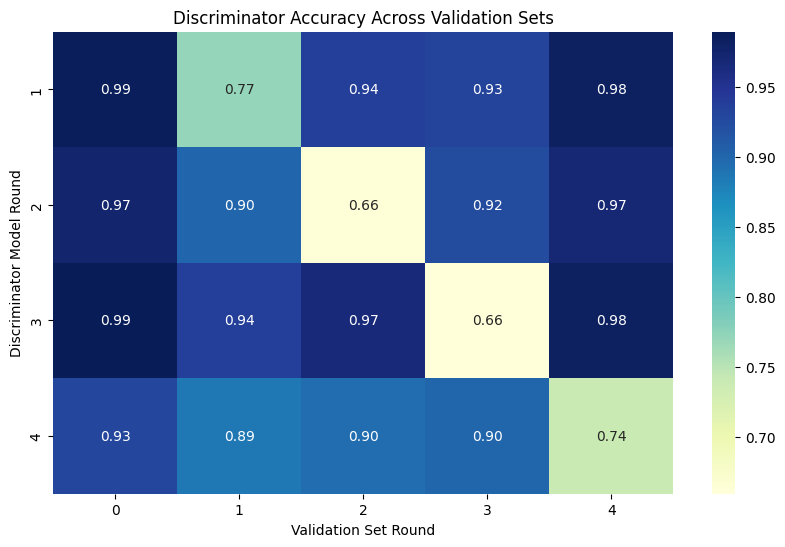

Evaluating:   0%|          | 0/30 [00:00<?, ?batch/s]

Before dropping duplicates: (606, 7)
After dropping duplicates: (136, 7)


Evaluating:   0%|          | 0/9 [00:00<?, ?batch/s]

Before dropping duplicates: (705, 7)
After dropping duplicates: (235, 7)


Evaluating:   0%|          | 0/15 [00:00<?, ?batch/s]

...

Evaluating:   0%|          | 0/15 [00:00<?, ?batch/s]

Before dropping duplicates: (764, 7)
After dropping duplicates: (294, 7)


Evaluating:   0%|          | 0/19 [00:00<?, ?batch/s]

Before dropping duplicates: (715, 7)
After dropping duplicates: (245, 7)


Evaluating:   0%|          | 0/16 [00:00<?, ?batch/s]

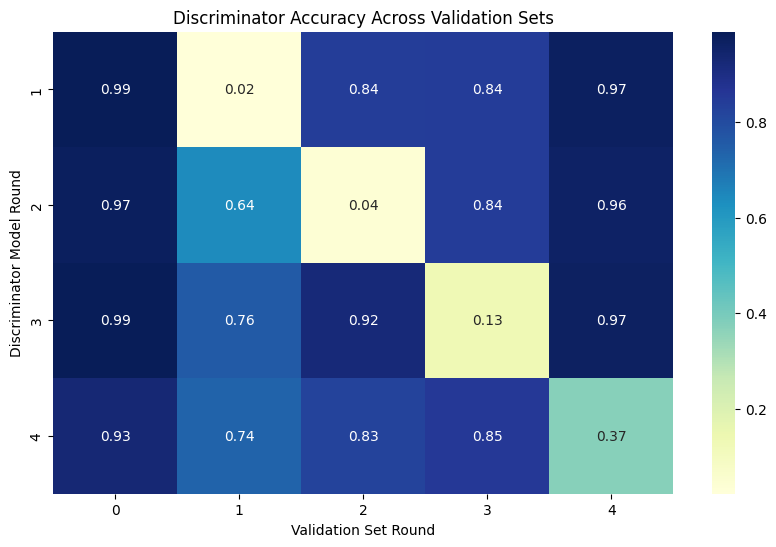

In [28]:
results = []
for model_round in range(1, rounds+1):
    model_dir = f"{save_dir}/round_{model_round}/model"
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.eval()
    if torch.cuda.is_available():
        model.to("cuda")

    for val_round in range(0, rounds+1):
        val_path = f"{val_save_dir}/augmented_validation_set_{val_round}.csv"
        val_df = pd.read_csv(val_path)
        acc = evaluate_model(model, tokenizer, val_df)  # your evaluation function
        results.append({
            "model_round": model_round,
            "val_round": val_round,
            "accuracy": acc
        })

results_df = pd.DataFrame(results)

heatmap_df = results_df.pivot(index="model_round", columns="val_round", values="accuracy")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Discriminator Accuracy Across Validation Sets")
plt.xlabel("Validation Set Round")
plt.ylabel("Discriminator Model Round")
plt.show()


# NEW VAL LOGIC 
results = []
original_clean_df = pd.read_csv("CEAS_08.csv") 
for model_round in range(1, rounds+1):
    model_dir = f"{save_dir}/round_{model_round}/model"
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.eval()
    if torch.cuda.is_available():
        model.to("cuda")

    for val_round in range(0, rounds+1):
        val_path = f"{val_save_dir}/augmented_validation_set_{val_round}.csv"
        val_df = pd.read_csv(val_path)

        if val_round == 0:
            acc = evaluate_model(model, tokenizer, val_df)  # your evaluation function
            results.append({
                "model_round": model_round,
                "val_round": val_round,
                "accuracy": acc
            })
            continue

        # For second type of evaluation, drop samples that are in the original clean dataset
        print("Before dropping duplicates:", val_df.shape)
        val_df = val_df[~val_df["body"].isin(original_clean_df["body"])]
        print("After dropping duplicates:", val_df.shape)

        acc = evaluate_model(model, tokenizer, val_df)  # your evaluation function
        results.append({
            "model_round": model_round,
            "val_round": val_round,
            "accuracy": acc
        })

results_df = pd.DataFrame(results)

heatmap_df = results_df.pivot(index="model_round", columns="val_round", values="accuracy")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Discriminator Accuracy Across Validation Sets")
plt.xlabel("Validation Set Round")
plt.ylabel("Discriminator Model Round")
plt.show()